# Vehicle Loan Default Prediction
Machine Learning (ML) Zoomcamp Capstone #1 Project

In [149]:
# FIXME  Rewrite using new data schema and objectives

## Objectives

- [ ] Consider traits and insights that can be gleaned from the dataset to guide / understand the impacts on employees.
- [ ] Targeting the `Attrition` feature, build a machine learning model to predict whether a given employee is likely to churn
- [ ] Rank features that promote or reduce the likelihood of churn
- [ ] "Operationalise" the machine learning model by wrapping it in an API, itself wrapped into a Docker container to create a microservice that can be used directly from any application that supports REST integration
- [ ] Document findings, ML model design and selection, the API, and Docker container

This showcase demonstrates improved competency via:

- [x] Rich output in scripts and notebooks
- [x] chained dataframe cleaning, eda, plots, etc => vastly reduce memory allocation / optimise for garbage collection => performance gains
- [ ] feature correlation, feature selection, and plots
- [x] Impute, standardisation, log1p
- [ ] automated hyperparameter tuning
- [ ] train vs validation data ROC plots, showing tuning outcomes per model type -> now choose
- [ ] actual vs predicted plots, showing tuning outcomes per model type -> now choose
- [ ] kind (kubernetes local) deployment

## Imports

In [227]:
from IPython.display import display
from rich.jupyter import print
%load_ext rich

import numpy as np
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import RocCurveDisplay, roc_auc_score, roc_curve, root_mean_squared_error # , f1_score, mutual_info_score, auc
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text #, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from itertools import combinations
from typing import Iterable, TypeVar, Optional, Dict, Callable

skPredict = TypeVar("skPredict", LogisticRegression, DecisionTreeClassifier, RandomForestClassifier)
skDecide = TypeVar("skDecide", skPredict, LinearRegression, DecisionTreeRegressor, RandomForestRegressor)
skFit = TypeVar("skFit", skPredict, skDecide)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm.auto import tqdm

import xgboost as xgb

The rich extension is already loaded. To reload it, use:
  %reload_ext rich


### Display versions

In [151]:
%%time 

from platform import python_version
import arff
import sklearn as sk
import matplotlib as mpl
import tqdm as tq
import subprocess as cmd

versions = {
    "python": python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "liac-arff": arff.__version__,
    "sklearn": sk.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
    "tqdm": tq.__version__,
}

for line in cmd.check_output(["jupyter", "--version"]).decode().split('\n'):
    comps = list( map(str.strip, line.split(': ')) )
    if len(comps) == 2:
        versions[comps[0]] = comps[1]
    
print( dict( sorted(versions.items() )))

del python_version, arff, sk, mpl, tq, cmd, line, comps, versions

{
    'IPython': '8.30.0',
    'ipykernel': '6.29.5',
    'ipywidgets': '8.1.5',
    'jupyter_client': '8.6.3',
    'jupyter_core': '5.7.2',
    'jupyter_server': 'not installed',
    'jupyterlab': 'not installed',
    'liac-arff': '2.4.0',
    'matplotlib': '3.10.0',
    'nbclient': 'not installed',
    'nbconvert': 'not installed',
    'nbformat': 'not installed',
    'notebook': 'not installed',
    'numpy': '1.26.4',
    'pandas': '2.2.3',
    'python': '3.11.6',
    'qtconsole': 'not installed',
    'seaborn': '0.13.2',
    'sklearn': '1.4.0',
    'tqdm': '4.67.1',
    'traitlets': '5.14.3'
}

CPU times: total: 0 ns
Wall time: 1.88 s


In [152]:
# %%time

# from rich.progress import track
# import time

# for i in track(range(100), description="Processing..."):
#     time.sleep(0.02)

## Utilities

In [153]:
strip_whitespace = lambda val: val.strip() if type(val) is str else val

In [154]:
# https://stackoverflow.com/questions/1175208/elegant-python-function-to-convert-camelcase-to-snake-case
import re

def to_snake_case(name) -> str:
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    return name.replace(' ','_').replace('__','_').replace('.', '_').replace('(', '').replace(')', '').lower()

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.map(to_snake_case)
    return df

# print(to_snake_case('camel2_camel2_case'))   # camel2_camel2_case
# print(to_snake_case('camel2C Camel2_Case'))  # camel2_camel2_case
# print(to_snake_case('getHTTPResponseCode'))  # get_http_response_code
# print(to_snake_case('HTTPResponseCodeXYZ'))  # http_response_code_xyz

In [155]:
def scalar_features(df: pd.DataFrame, exclude: Iterable[str] = [], ascending: Optional[bool] = None) -> Iterable[str]:
    cols = df.select_dtypes(exclude=[object, 'category']).columns
    cols = cols if ascending == None else cols.sort_values(ascending=ascending)
    return [col for col in cols if col not in exclude]

def categorical_features(df: pd.DataFrame, exclude: Iterable[str] = [], ascending: Optional[bool] = None) -> Iterable[str]:
    cols = df.select_dtypes(include=[object, 'category']).columns
    cols = cols if ascending == None else cols.sort_values(ascending=ascending)
    return [col for col in cols if col not in exclude]

In [156]:
def get_lookup_value(id: int, df_lookup: pd.DataFrame, col:str = 'level', ifNull:str = 'Not Answered') -> str:
    return f'{ int(id) } { df_lookup.loc[id][col] }' if id in df_lookup.index else ifNull

In [157]:
def validation_testing_training_full_split(dataframe: pd.DataFrame, seed: int = 42, validation: float = 0.2, testing: float = 0.2) \
    -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    assert 0 < validation and 0 < testing and 1 > (validation + testing)

    validation_of_full = validation / (1 - testing)
    if validation_of_full == 0:
        validation_of_full = None
        
    df_full,     df_testing    = train_test_split(dataframe, test_size=testing,            random_state=seed, shuffle=True)
    df_training, df_validation = train_test_split(df_full,   test_size=validation_of_full, random_state=seed, shuffle=True)
    
    df_validation = df_validation.reset_index(drop=True)
    df_testing = df_testing.reset_index(drop=True)
    df_training = df_training.reset_index(drop=True)
    df_full = df_full.reset_index(drop=True)
    
    return df_validation, df_testing, df_training, df_full

In [158]:
def y_split(dataframe: pd.DataFrame, yColumn: str, drop: Iterable[str] = []) -> tuple[pd.DataFrame, pd.Series]:
    columns = set(dataframe.columns)   
    assert columns.issuperset([yColumn]), f'{yColumn} not found in dataframe'
    assert columns.issuperset(drop), f'At least one of {drop} not found in dataframe'
    
    df = dataframe.copy()
    y = df[yColumn]
    for col in [*drop, yColumn]:
        del df[col]
        
    return df, y

In [159]:
def regularize(X, r=0.000000001):
    return X + np.eye(X.shape[0]) * r

In [160]:
# def regularize(X, r: float = 0.00000001):
#     return X if r == 1 else X + np.eye(X.shape[0]) * r
#     
# X = [
#     [1, 2, 2],
#     [2, 1, 1], # r
#     [2, 1, 1], # r
#     [0, 9, 9],
#     [1, 0, 0],
# ] #     c  c
# X = np.array(X)
# XTX = X.T.dot(X)
# print(XTX) # duplicate columns is an issue for linear / logistic regression
# np.linalg.inv(XTX)
# 
# regularize(X, r=0.01)

In [161]:
def sigmoid(score):
    return 1 / (1 + np.exp(-score))

# z = np.linspace(-5, 5, 51)
# plt.plot(z, sigmoid(z))

In [162]:
def display_predictive_features_for_target(df: pd.DataFrame, target: str, categorical: Iterable[str] = []):
    global_target = df[target].mean()
    for c in categorical:
        df_group = df.groupby(c)[target].agg('mean','count')
        df_group['diff'] = df_group.mean() - global_target
        df_group['risk'] = df_group.mean() / global_target
        display(df_group)

In [163]:
def one_hot_encode(dataframe: pd.DataFrame, vectorizer: DictVectorizer = DictVectorizer(sparse=False), drop: Iterable[str] = [], fit: bool = False):
    assert set(dataframe.columns).issuperset(drop), f'At least one of {drop} is not found in the dataFrame'
    
    df_encode = dataframe.copy()
    for feature in drop:
        # print(f'one_hot_encode: dropping {feature = }')
        del df_encode[feature]
        
        
    # print(f'one_hot_encode: vectorizer is DictVectorizer? { isinstance(vectorizer, DictVectorizer) }')
    data = df_encode.to_dict(orient='records') if isinstance(vectorizer, DictVectorizer) else df_encode.values
    X = vectorizer.fit_transform(data) if fit else vectorizer.transform(data)
    
    # print(f'one_hot_encode: { X[0] = }, length of { len( X[0] ) }')
        
    if isinstance(vectorizer, DictVectorizer):
        assert len(vectorizer.feature_names_) == X.shape[1]
    return X, vectorizer

In [164]:
def fit(model: skFit, dataframe: pd.DataFrame, y: pd.Series, vectorizer: DictVectorizer = DictVectorizer(sparse=False), drop: Iterable[str] = []) -> tuple[skFit, DictVectorizer]:
    assert dataframe.shape[0] == y.shape[0], '`dataframe` and `y` mismatch'
    
    X, vectorizer = one_hot_encode(dataframe, vectorizer, drop, fit=True)
    model.fit(X, y.values)
    
    return model, vectorizer

In [165]:
def score(model: skFit, vectorizer: DictVectorizer, dataframe: pd.DataFrame, y: pd.Series, drop: Iterable[str] = []):
    X, _ = one_hot_encode(dataframe, vectorizer, drop)
    return model.score(X, y.values)

In [166]:
def decide(model: skDecide, vectorizer: DictVectorizer, dataframe: pd.DataFrame, drop: Iterable[str] = []):
    X, _ = one_hot_encode(dataframe, vectorizer, drop)
    y_pred = model.predict(X)
    
    return y_pred

In [167]:
def predict(model: skPredict, vectorizer: DictVectorizer, dataframe: pd.DataFrame, drop: Iterable[str] = []):
    X, _ = one_hot_encode(dataframe, vectorizer, drop)
    y_pred = model.predict_proba(X)[:, 1]
    
    return y_pred

In [168]:
def random_predictions(y: pd.Series, seed: int = 42):
    np.random.seed(seed)
    if y.dtype == 'bool':
        return np.random.uniform(0, 1, size=len(y))
    else:
        return np.random.uniform(0, 1, size=len(y))

In [169]:
def model_metrics(y: pd.Series, y_pred: pd.Series, threshold: float = 0.5):
    assert len(y) == len(y_pred), "`y` and `y_pred` mismatch"
    assert 0 <= threshold and threshold <= 1, "invalid threshold"
    
    actual_positive = (y == 1)
    actual_negative = (y == 0)
    predicted_positive = (y_pred >= threshold)
    predicted_negative = (y_pred < threshold)
    
    true_positive = (predicted_positive & actual_positive).sum()
    false_positive = (predicted_positive & actual_negative).sum()
    false_negative = (predicted_negative & actual_positive).sum()
    true_negative = (predicted_negative & actual_negative).sum()
    
    # Accuracy = ratio of correct predictions -- false and positive 
    # accuracy = proportional_matrix[0,0] + proportional_matrix[1,1]
    accuracy = (true_positive + true_negative) / (true_positive + false_positive + false_negative + true_negative)
    
    # Precision = ratio of correct to positive predictions; higher is better
    precision = true_positive / (true_positive + false_positive)
    # Recall = ratio of correctly predicted positive; higher is better
    recall = true_positive / (true_positive + false_negative)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    # TPR = ratio of true positives in all positives; higher is better
    # true_positive_rate = recall
    true_positive_rate  = true_positive / ( false_negative + true_positive)
    # FPR = ratio of false positives in all negatives; lower is better
    false_positive_rate = false_positive / (true_negative + false_positive)
    
    matrix = np.array([
        #   g(Xi) < t    |   g(Xi) >= t
        [ true_negative  , false_positive ], # y == 0
        [ false_negative , true_positive  ]  # y == 1
    ])
    
    proportional_matrix = (matrix / matrix.sum()).round(6)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': true_positive,
        'fp': false_positive,
        'fn': false_negative,
        'tn': true_negative,
        'tpr': true_positive_rate,
        'fpr': false_positive_rate,
        'confusion': matrix,
        'proportional_confusion': proportional_matrix
    }

In [170]:
def model_metrics_for_thresholds(y: pd.Series, y_pred: pd.Series, thresholds: Iterable[float]) -> pd.DataFrame:
    results = []
    for threshold in thresholds:
        metrics = model_metrics(y, y_pred, threshold)
        metrics['threshold'] = threshold
        results.append(metrics)
        
    df_metrics = pd.DataFrame(results)
    df_metrics.set_index('threshold', inplace=True)
    
    return df_metrics

In [171]:
def all_combinations_of(arr):
    return (combo for choose in range(1 + len(arr)) for combo in map(list, combinations(arr, choose)))

In [172]:
def memory_consumption_of(df: pd.DataFrame, preamble: str = 'memory consumption = ', postamble: str = ' MB') -> pd.DataFrame:
    return print(f'{ preamble }{ round( df.memory_usage(deep=True).sum() / 1024 / 1024, 2) }{ postamble }') or df

def shape_of(df: pd.DataFrame, preamble: str = 'shape = ', postamble: str = '') -> pd.DataFrame:
    return print(f'{ preamble }{ df.shape }{ postamble }') or df

def save_to(df: pd.DataFrame, global_var: str = 'df') -> pd.DataFrame:
    key = global_var or 'df'
    print(f'saving to { key }')
    globals()[key] = df 
    return df

## Data Preparation

In [173]:
# FIXME  Rewrite using new data schema and objectives

### Performance Ratings / `dfPerformance`:

<!---  https://www.markdownguide.org/extended-syntax/ --->

PerformanceID
:   Unique identifier for each performance review.

EmployeeID
:   Unique identifier for the employee being reviewed.

ReviewDate
:   The date of the performance review.

EnvironmentSatisfaction
:   Rating of the employee's satisfaction with their work environment.

JobSatisfaction
:   Rating of the employee's satisfaction with their job.

RelationshipSatisfaction
:   Rating of the employee's satisfaction with workplace relationships.

TrainingOpportunitiesWithinYear
:   Number of training opportunities available to the employee within the year.

TrainingOpportunitiesTaken
:   Number of training opportunities the employee has taken.

WorkLifeBalance
:   Rating of the employee's work-life balance.

SelfRating
:   The employee's self-assessment rating.

ManagerRating
:   The manager's rating of the employee's performance.


### Employees / `dfEmployee`:

EmployeeID
:   Unique identifier for each employee.

FirstName
:   The first name of the employee.

LastName
:   The last name of the employee.

Gender
:   The gender of the employee.

Age
:   The age of the employee.

BusinessTravel
:   The frequency of business travel for the employee.

Department
:   The department in which the employee works.

DistanceFromHome (KM)
:   The distance between the employee's home and workplace in kilometers.

State
:   The state in which the employee resides.

Ethnicity
:   The ethnicity of the employee.

MaritalStatus
:   The marital status of the employee.

Salary
:   The annual salary of the employee.

StockOptionLevel
:   The level of stock options granted to the employee.

OverTime
:   Whether the employee works overtime (Yes/No).

HireDate
:   The date the employee was hired.

Attrition
:   Whether the employee has left the company (Yes/No).

YearsAtCompany
:   The number of years the employee has been with the company.

YearsInMostRecentRole
:   The number of years the employee has been in their most recent role.

YearsSinceLastPromotion
:   The number of years since the employee's last promotion.

YearsWithCurrManager
:   The number of years the employee has worked with their current manager.

### Load Data

In [174]:
def clean_from_raw(dataframe: pd.DataFrame) -> pd.DataFrame:
    def fix_raw_date(series: pd.Series) -> pd.Series:
        """Converts the raw dataset's date values into a Numpy Series of dates"""
        
        # df['date_col'] =  pd.to_datetime(df['date_col'], format='%d/%m/%Y')
        # df[['start_date', 'end_date']] = df[['start_date', 'end_date']].apply(pd.to_datetime, format="%m/%d/%Y")
        # df['date'] = df['date'].astype('datetime64[ns]') or use datetime64[D] if you want Day precision and not nanoseconds

        # display(series.value_counts(dropna=False).sort_index())
        # ASSUME -> FIX `01-01-00` is 2000, not 1900
        
        _df = pd.DataFrame(series).join(series.str.split('-', expand=True))
        _df.columns = ['date', 'd', 'm', 'y']
        _df.loc[_df.y == '00', 'c'] = '20'
        _df.fillna({ 'c': '19' }, inplace=True)
        _df['yyyy'] = _df.c + _df.y
        
        _df.date = _df.date.str[:6] + _df.yyyy
        
        return pd.to_datetime(_df.date, dayfirst=True, format='%d-%m-%Y')

    def fix_raw_timedelta(series: pd.Series) -> pd.Series:
        """Converts the raw dataset's time delta values into a Numpy Series of uint8 (months)"""
        # display(series.value_counts(dropna=False).sort_index())
        
        _df =  pd.DataFrame(series).join(series.str.split('yrs ', expand=True))
        _df.columns = ['delta', 'yrs', 'remainder']
        _df['months'] = _df.remainder.str.split('mon', expand=True)[0]
        
        _df = _df.astype({
            'yrs'   : np.uint8,
            'months': np.uint8,
        })
        
        return _df.yrs * 12 + _df.months

    def fix_raw_risk(series: pd.Series) -> pd.Series:
        description = series.str.lower()
        
        no_history = (description.str.contains('history') | description.str.contains('enough info'))
        very_high = description.str.contains('very high')
        high = description.str.contains('high')
        medium = description.str.contains('medium')
        low = description.str.contains('low')
        very_low = description.str.contains('very low')
        
        return np.select(
            [ very_high,   very_low,   high,   medium,   low,   no_history],
            ['very high', 'very low', 'high', 'medium', 'low', 'no history'],
            'not scored'
        )
    
    return (dataframe
        .rename(columns={
            "uniqueid"              : "unique_id",
            "disbursaldate"         : "disbursal_date",
        })
        .assign(
            date_of_birth           = lambda _: fix_raw_date(_.date_of_birth),
            employment_type         = lambda _: _.employment_type.str.lower(),              # .fillna('Other')
            disbursal_date          = lambda _: fix_raw_date(_.disbursal_date),
            mobileno_avl_flag       = lambda _: _.mobileno_avl_flag == 1,
            aadhar_flag             = lambda _: _.aadhar_flag == 1,
            pan_flag                = lambda _: _.pan_flag == 1,
            voterid_flag            = lambda _: _.voterid_flag == 1,
            driving_flag            = lambda _: _.driving_flag == 1,
            passport_flag           = lambda _: _.passport_flag == 1,
            perform_cns_score_description = lambda _: fix_raw_risk(_.perform_cns_score_description),  # TODO very low < low < medium < ...
            average_acct_age        = lambda _: fix_raw_timedelta(_.average_acct_age),
            credit_history_length   = lambda _: fix_raw_timedelta(_.credit_history_length),
        )
        .astype({
            "unique_id"             : np.uint32,
            "disbursed_amount"      : np.float32,
            "asset_cost"            : np.float32,
            "ltv"                   : np.uint8,
            # "branch_id"      
            # "supplier_id"    
            # "manufacturer_id"
            # "current_pincode_id"
            # "date_of_birth"
            # "employment_type"                           # TODO has 7661 missing values  -> sparce w/ onerror=ignore
            # "disbursal_date"
            # "state_id"       
            # "employee_code_id"
            # "mobileno_avl_flag"
            # "aadhar_flag"      
            # "pan_flag"         
            # "voterid_flag"     
            # "driving_flag"     
            # "passport_flag"    
            "perform_cns_score"     : np.uint16,
            # "perform_cns_score_description"
            "pri_no_of_accts"       : np.uint16,
            "pri_active_accts"      : np.uint16,
            "pri_overdue_accts"     : np.uint16,
            "pri_current_balance"   : np.float64,
            "pri_sanctioned_amount" : np.float64,
            "pri_disbursed_amount"  : np.float64,
            "sec_no_of_accts"       : np.uint16,
            "sec_active_accts"      : np.uint16,
            "sec_overdue_accts"     : np.uint16,
            "sec_current_balance"   : np.float64,
            "sec_sanctioned_amount" : np.float64,
            "sec_disbursed_amount"  : np.float64,
            "primary_instal_amt"    : np.float64,
            "sec_instal_amt"        : np.float64,
            "new_accts_in_last_six_months"          : np.uint8,
            "delinquent_accts_in_last_six_months"   : np.uint8,
            # "average_acct_age"
            # "credit_history_length"
            "no_of_inquiries"       : np.uint8,
            "loan_default"          : np.uint8,
            **{ col: 'category' for col in ['branch_id', 
                                            'supplier_id',
                                            'manufacturer_id', 
                                            'current_pincode_id',
                                            'employment_type',
                                            'state_id', 
                                            'employee_code_id',
                                            'perform_cns_score_description'
                                            ] }
        })
    )

In [175]:
def feature_engineering(dataframe: pd.DataFrame) -> pd.DataFrame:
    return (dataframe
        .assign(
            date_of_birth_year        = lambda _: _.date_of_birth.dt.year,
            date_of_birth_yq          = lambda _: _.date_of_birth.dt.to_period('Q'),
            date_of_birth_quarter     = lambda _: _.date_of_birth.dt.quarter,
            date_of_birth_ym          = lambda _: _.date_of_birth.dt.to_period('M'),
            date_of_birth_month       = lambda _: _.date_of_birth.dt.month,
            date_of_birth_dow         = lambda _: _.date_of_birth.dt.day_of_week,
            date_of_birth_is_weekend  = lambda _: _.date_of_birth.dt.day_of_week.isin([5, 6]),

            disbursal_date_year       = lambda _: _.disbursal_date.dt.year,
            disbursal_date_yq         = lambda _: _.disbursal_date.dt.to_period('Q'),
            disbursal_date_quarter    = lambda _: _.disbursal_date.dt.quarter,
            disbursal_date_ym         = lambda _: _.disbursal_date.dt.to_period('M'),
            disbursal_date_month      = lambda _: _.disbursal_date.dt.month,
            disbursal_date_dow        = lambda _: _.disbursal_date.dt.day_of_week,
            disbursal_date_is_weekend = lambda _: _.disbursal_date.dt.day_of_week.isin([5, 6]),
        )
    )

In [255]:
def preprocessing(dataframe: pd.DataFrame, scaler, scale: Iterable[str] = [], categorical: Dict[str, Callable[[pd.Series], pd.DataFrame]] = {}, drop: Iterable[str] = []) -> pd.DataFrame:
    assert scaler, 'a scaler is required'
    assert len(scale) >= 0
    assert len(drop) >= 0
    columns = set(dataframe.columns)
    assert columns.issuperset(scale), f'At least one of {scale} not found in dataframe'
    assert columns.issuperset(categorical.keys()), f'At least one of {scale} not found in dataframe'
    assert columns.issuperset(drop),  f'At least one of {drop} not found in dataframe'
    
    print(f'{categorical = }')
    dfCategorical: pd.DataFrame = None
    for feature, transformer in categorical.items():
        try:
            print(f'{feature}: {transformer}')
            A = transformer(dataframe[feature])
            print(f'{feature}:\n{A = }')
        finally:
            print(f'{feature}: done!')
    
    scaled_features = scaler.fit_transform(dataframe[scale])
    df_scaled = pd.DataFrame(scaled_features, columns=[col+'_scaled' for col in scale])
    
    return (dataframe
        .drop(scale, axis=1)
        .join(df_scaled)
        .drop(drop, axis=1)
        # .assign(
        #     employment_type         = lambda _: _.employment_type.fillna(''),
        # )
        .set_index('unique_id')
    )

In [276]:
def top_n_encoder(series: pd.Series, top_n: int = 10) -> pd.DataFrame:
    assert isinstance(series, pd.Series), 'series is required'
    assert top_n >= 1, 'top_n must be greater than 0'
    
    df_X = (pd.DataFrame(series, index=series.index)
            .drop(columns=[series.name])
            )
    
    try:
        for value in (series
                        .value_counts(ascending=False)
                        .head(top_n)
                        .index
                        .values
                    ):
            df_X[f'{series.name}={value}'] = np.where( series == value , 1, 0 ).astype('uint8')
        return df_X 
    except Exception as xp:
        print(f'top_n_encoder: EXCEPTION { xp = }')
        return pd.DataFrame(series, index=series.index)
    

#### Load raw .arff data into a DataFrame

In [277]:
%%time
# from scipy.io import arff   # FAILED as "NotImplementedError: String attributes not supported yet"
import arff

raw = arff.load( open('./data/LT-Vehicle-Loan-Default-Prediction.arff', 'r') )

print(raw.keys())
print(raw['attributes'])

columns = [to_snake_case(name) for name, type in raw['attributes']]
print(f"{columns = }")

scaler = StandardScaler()
# vectorizer = DictVectorizer(sparse=False)
# vectorizer = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

features_to_scale = [
    'disbursed_amount',
    'asset_cost',
    'pri_current_balance',
    'pri_sanctioned_amount',
    'pri_disbursed_amount',
    'sec_current_balance',
    'sec_sanctioned_amount',
    'sec_disbursed_amount',
]

features_to_encode = {
    # 'branch_id': lambda _: _,
    # 'supplier_id': lambda _: _,
    # 'manufacturer_id': lambda _: _,
    # 'current_pincode_id': lambda _: _,
    'employment_type'                   : lambda _: top_n_encoder(_, 2),
    # 'state_id': lambda _: _,
    # 'employee_code_id': lambda _: _,
    # 'perform_cns_score_description': lambda _: _,
}

features_not_compatible_with_modelling = [
    'date_of_birth',
    'date_of_birth_yq',
    'date_of_birth_ym',
    'disbursal_date',
    'disbursal_date_yq',
    'disbursal_date_ym',
    'employment_type'    # HACK remove
]

dfLoans_processed = (
    pd.DataFrame(np.array(raw['data']), columns=columns)
    
    .pipe(save_to, "df_raw")
    
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    .pipe(clean_from_raw)
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    
    .pipe(save_to, "df_cleaned")
    
    .pipe(feature_engineering)
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    
    .pipe(save_to, "dfLoans")
    
    .pipe(preprocessing, scaler, scale=features_to_scale, categorical=features_to_encode, drop=features_not_compatible_with_modelling)
    .pipe(shape_of)
    .pipe(memory_consumption_of)
)

del arff, raw, columns

dict_keys(['description', 'relation', 'attributes', 'data'])

[
    ('uniqueid', 'INTEGER'),
    ('disbursed_amount', 'INTEGER'),
    ('asset_cost', 'INTEGER'),
    ('ltv', 'REAL'),
    ('branch_id', 'INTEGER'),
    ('supplier_id', 'INTEGER'),
    ('manufacturer_id', 'INTEGER'),
    ('current_pincode_id', 'INTEGER'),
    ('date.of.birth', 'STRING'),
    ('employment.type', 'STRING'),
    ('disbursaldate', 'STRING'),
    ('state_id', 'INTEGER'),
    ('employee_code_id', 'INTEGER'),
    ('mobileno_avl_flag', 'INTEGER'),
    ('aadhar_flag', 'INTEGER'),
    ('pan_flag', 'INTEGER'),
    ('voterid_flag', 'INTEGER'),
    ('driving_flag', 'INTEGER'),
    ('passport_flag', 'INTEGER'),
    ('perform_cns.score', 'INTEGER'),
    ('perform_cns.score.description', 'STRING'),
    ('pri.no.of.accts', 'INTEGER'),
    ('pri.active.accts', 'INTEGER'),
    ('pri.overdue.accts', 'INTEGER'),
    ('pri.current.balance', 'INTEGER'),
    ('pri.sanctioned.amount', 'INTEGER'),
    ('pri.disbursed.amount', 'INTEGER'),
    ('sec.no.of.accts', 'INTEGER'),
    ('sec.active.accts', 'INTEGER'),
    ('sec.overdue.accts', 'INTEGER'),
    ('sec.current.balance', 'INTEGER'),
    ('sec.sanctioned.amount', 'INTEGER'),
    ('sec.disbursed.amount', 'INTEGER'),
    ('primary.instal.amt', 'INTEGER'),
    ('sec.instal.amt', 'INTEGER'),
    ('new.accts.in.last.six.months', 'INTEGER'),
    ('delinquent.accts.in.last.six.months', 'INTEGER'),
    ('average.acct.age', 'STRING'),
    ('credit.history.length', 'STRING'),
    ('no.of_inquiries', 'INTEGER'),
    ('loan_default', ['0', '1'])
]

columns = ['uniqueid', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 
'current_pincode_id', 'date_of_birth', 'employment_type', 'disbursaldate', 'state_id', 'employee_code_id', 
'mobileno_avl_flag', 'aadhar_flag', 'pan_flag', 'voterid_flag', 'driving_flag', 'passport_flag', 
'perform_cns_score', 'perform_cns_score_description', 'pri_no_of_accts', 'pri_active_accts', 'pri_overdue_accts', 
'pri_current_balance', 'pri_sanctioned_amount', 'pri_disbursed_amount', 'sec_no_of_accts', 'sec_active_accts', 
'sec_overdue_accts', 'sec_current_balance', 'sec_sanctioned_amount', 'sec_disbursed_amount', 'primary_instal_amt', 
'sec_instal_amt', 'new_accts_in_last_six_months', 'delinquent_accts_in_last_six_months', 'average_acct_age', 
'credit_history_length', 'no_of_inquiries', 'loan_default']

saving to df_raw

shape = (233154, 41)

...

employment_type:
A =         employment_type=self employed  employment_type=salaried
0                                   0                         1
1                                   1                         0
2                                   1                         0
3                                   1                         0
4                                   1                         0
...                               ...                       ...
233149                              0                         1
233150                              1                         0
233151                              0                         1
233152                              0                         1
233153                              0                         1

[233154 rows x 2 columns]

employment_type: done!

shape = (233154, 47)

memory consumption = 35.01 MB

CPU times: total: 31.7 s
Wall time: 37.4 s


 df_X =       |  employment_type=self employed  | employment_type=salaried
 :--------    |     :--------:    |      :------------:
0             |                  False          |             True
1             |                   True          |            False
2             |                   True          |            False
3             |                   True          |            False
4             |                   True          |            False
...           |                    ...          |              ...
233149        |                  False          |             True
233150        |                   True          |            False
233151        |                  False          |             True
233152        |                  False          |             True
233153        |                  False          |             True

#### Numpy data types

In [179]:
#TODO improve output display

for dt in map(np.finfo, [np.float64, np.float32, np.float16]):
    print(dt)
for dt in map(np.iinfo, [np.int64, np.int32, np.int16, np.int8,  np.uint64, np.uint32, np.uint16, np.uint8]):
    print(dt)

Machine parameters for float64
---------------------------------------------------------------
precision =  15   resolution = 1.0000000000000001e-15
machep =    -52   eps =        2.2204460492503131e-16
negep =     -53   epsneg =     1.1102230246251565e-16
minexp =  -1022   tiny =       2.2250738585072014e-308
maxexp =   1024   max =        1.7976931348623157e+308
nexp =       11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 4.9406564584124654e-324
---------------------------------------------------------------

Machine parameters for float32
---------------------------------------------------------------
precision =   6   resolution = 1.0000000e-06
machep =    -23   eps =        1.1920929e-07
negep =     -24   epsneg =     5.9604645e-08
minexp =   -126   tiny =       1.1754944e-38
maxexp =    128   max =        3.4028235e+38
nexp =        8   min =        -max
smallest_normal = 1.1754944e-38   smallest_subnormal = 1.4012985e-45
---------------------------------------------------------------

Machine parameters for float16
---------------------------------------------------------------
precision =   3   resolution = 1.00040e-03
machep =    -10   eps =        9.76562e-04
negep =     -11   epsneg =     4.88281e-04
minexp =    -14   tiny =       6.10352e-05
maxexp =     16   max =        6.55040e+04
nexp =        5   min =        -max
smallest_normal = 6.10352e-05   smallest_subnormal = 5.96046e-08
---------------------------------------------------------------

Machine parameters for int64
---------------------------------------------------------------
min = -9223372036854775808
max = 9223372036854775807
---------------------------------------------------------------

Machine parameters for int32
---------------------------------------------------------------
min = -2147483648
max = 2147483647
---------------------------------------------------------------

...

Machine parameters for int8
---------------------------------------------------------------
min = -128
max = 127
---------------------------------------------------------------

Machine parameters for uint64
---------------------------------------------------------------
min = 0
max = 18446744073709551615
---------------------------------------------------------------

Machine parameters for uint32
---------------------------------------------------------------
min = 0
max = 4294967295
---------------------------------------------------------------

Machine parameters for uint16
---------------------------------------------------------------
min = 0
max = 65535
---------------------------------------------------------------

Machine parameters for uint8
---------------------------------------------------------------
min = 0
max = 255
---------------------------------------------------------------

#### Clean raw dataframe

In [180]:
(df_raw
    .dtypes
)


uniqueid                               object
disbursed_amount                       object
asset_cost                             object
ltv                                    object
branch_id                              object
supplier_id                            object
manufacturer_id                        object
current_pincode_id                     object
date_of_birth                          object
employment_type                        object
disbursaldate                          object
state_id                               object
employee_code_id                       object
mobileno_avl_flag                      object
aadhar_flag                            object
pan_flag                               object
voterid_flag                           object
driving_flag                           object
passport_flag                          object
perform_cns_score                      object
perform_cns_score_description          object
pri_no_of_accts                  

In [181]:
(df_raw
    .pipe(memory_consumption_of)
    .describe(include='all')
    .round(1)
    .T
)

memory consumption = 374.83 MB

,count,unique,top,freq
uniqueid,233154,233154,420825,1
disbursed_amount,233154,24565,48349,2140
asset_cost,233154,46252,68000,681
ltv,233154.0,6579.0,85.0,4430.0
branch_id,233154,82,2,13138
supplier_id,233154,2953,18317,1432
manufacturer_id,233154,11,86,109534
current_pincode_id,233154,6698,2578,1880
date_of_birth,233154,15433,01-01-88,2173
employment_type,225493,2,Self employed,127635


In [182]:
# %%time

# def fix_raw_date(series: pd.Series) -> pd.Series:
#     """Converts the raw dataset's date values into a Numpy Series of dates"""
    
#     # df['date_col'] =  pd.to_datetime(df['date_col'], format='%d/%m/%Y')
#     # df[['start_date', 'end_date']] = df[['start_date', 'end_date']].apply(pd.to_datetime, format="%m/%d/%Y")
#     # df['date'] = df['date'].astype('datetime64[ns]') or use datetime64[D] if you want Day precision and not nanoseconds

#     # display(series.value_counts(dropna=False).sort_index())
#     # ASSUME -> FIX `01-01-00` is 2000, not 1900
    
#     _df = pd.DataFrame(series).join(series.str.split('-', expand=True))
#     _df.columns = ['date', 'd', 'm', 'y']
#     _df.loc[_df.y == '00', 'c'] = '20'
#     _df.fillna({ 'c': '19' }, inplace=True)
#     _df['yyyy'] = _df.c + _df.y
    
#     _df.date = _df.date.str[:6] + _df.yyyy
    
#     return pd.to_datetime(_df.date, dayfirst=True, format='%d-%m-%Y')

# def fix_raw_timedelta(series: pd.Series) -> pd.Series:
#     """Converts the raw dataset's time delta values into a Numpy Series of uint8 (months)"""
#     # display(series.value_counts(dropna=False).sort_index())
    
#     _df =  pd.DataFrame(series).join(series.str.split('yrs ', expand=True))
#     _df.columns = ['delta', 'yrs', 'remainder']
#     _df['months'] = _df.remainder.str.split('mon', expand=True)[0]
    
#     _df = _df.astype({
#         'yrs'   : np.uint8,
#         'months': np.uint8,
#     })
    
#     return _df.yrs * 12 + _df.months

# def fix_raw_risk(series: pd.Series) -> pd.Series:
#     description = series.str.lower()
    
#     no_history = (description.str.contains('history') | description.str.contains('enough info'))
#     very_high = description.str.contains('very high')
#     high = description.str.contains('high')
#     medium = description.str.contains('medium')
#     low = description.str.contains('low')
#     very_low = description.str.contains('very low')
    
#     return np.select(
#         [ very_high,   very_low,   high,   medium,   low,   no_history],
#         ['very high', 'very low', 'high', 'medium', 'low', 'no history'],
#         'not scored'
#     )
    
# (df_raw
#     .pipe(memory_consumption_of)
#     .rename(columns={
#         "uniqueid"              : "unique_id",
#         "disbursaldate"         : "disbursal_date",
#     })
#     .assign(
#         date_of_birth           = lambda _: fix_raw_date(_.date_of_birth),
#         employment_type         = lambda _: _.employment_type.str.lower(),
#         disbursal_date          = lambda _: fix_raw_date(_.disbursal_date),
#         mobileno_avl_flag       = lambda _: _.mobileno_avl_flag == 1,
#         aadhar_flag             = lambda _: _.aadhar_flag == 1,
#         pan_flag                = lambda _: _.pan_flag == 1,
#         voterid_flag            = lambda _: _.voterid_flag == 1,
#         driving_flag            = lambda _: _.driving_flag == 1,
#         passport_flag           = lambda _: _.passport_flag == 1,
#         perform_cns_score_description = lambda _: fix_raw_risk(_.perform_cns_score_description),
#         average_acct_age        = lambda _: fix_raw_timedelta(_.average_acct_age),
#         credit_history_length   = lambda _: fix_raw_timedelta(_.credit_history_length),
#         loan_default            = lambda _: np.where(_.loan_default == '1', 'yes', 'no'),
#     )
#     .astype({
#         "unique_id"             : np.uint32,
#         "disbursed_amount"      : np.float32,
#         "asset_cost"            : np.float32,
#         "ltv"                   : np.uint8,
#         "branch_id"             : np.uint8,
#         "supplier_id"           : np.uint16,
#         "manufacturer_id"       : np.uint8,
#         "current_pincode_id"    : np.uint8,
#         # "date_of_birth"
#         "employment_type"       : 'category',   # TODO has 7661 missing values  -> sparce w/ onerror=ignore
#         # "disbursal_date"
#         "state_id"              : np.uint8,
#         "employee_code_id"      : np.uint16,
#         # "mobileno_avl_flag"
#         # "aadhar_flag"      
#         # "pan_flag"         
#         # "voterid_flag"     
#         # "driving_flag"     
#         # "passport_flag"    
#         "perform_cns_score"     : np.uint16,
#         "perform_cns_score_description": 'category',
#         "pri_no_of_accts"       : np.uint16,
#         "pri_active_accts"      : np.uint16,
#         "pri_overdue_accts"     : np.uint16,
#         "pri_current_balance"   : np.float64,
#         "pri_sanctioned_amount" : np.float64,
#         "pri_disbursed_amount"  : np.float64,
#         "sec_no_of_accts"       : np.uint16,
#         "sec_active_accts"      : np.uint16,
#         "sec_overdue_accts"     : np.uint16,
#         "sec_current_balance"   : np.float64,
#         "sec_sanctioned_amount" : np.float64,
#         "sec_disbursed_amount"  : np.float64,
#         "primary_instal_amt"    : np.float64,
#         "sec_instal_amt"        : np.float64,
#         "new_accts_in_last_six_months"          : np.uint8,
#         "delinquent_accts_in_last_six_months"   : np.uint8,
#         # "average_acct_age"
#         # "credit_history_length"
#         "no_of_inquiries"       : np.uint8,
#         "loan_default"          : 'category',
#         # **{ col: 'category' for col in ['employment_type', 'loan_default'] }
        
#     })
#     .pipe(save_to, "df_cleaned")
#     .pipe(memory_consumption_of)
# ) \
# .describe(include='all').round(1).T

In [183]:
df_raw.perform_cns_score_description.value_counts(ascending=False, dropna=False)


perform_cns_score_description
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the 

In [184]:
df_cleaned.perform_cns_score_description.value_counts(ascending=False, dropna=False)


perform_cns_score_description
no history    124387
very low       50728
low            18294
medium         12412
high           12025
very high       9910
not scored      5398
Name: count, dtype: int64

In [185]:
df_cleaned[categorical_features(df_cleaned)].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   branch_id                      233154 non-null  category
 1   supplier_id                    233154 non-null  category
 2   manufacturer_id                233154 non-null  category
 3   current_pincode_id             233154 non-null  category
 4   employment_type                225493 non-null  category
 5   state_id                       233154 non-null  category
 6   employee_code_id               233154 non-null  category
 7   perform_cns_score_description  233154 non-null  category
dtypes: category(8)
memory usage: 3.0 MB


In [186]:
df_cleaned[df_cleaned.unique_id.duplicated()]

,unique_id,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,current_pincode_id,date_of_birth,employment_type,...,sec_sanctioned_amount,sec_disbursed_amount,primary_instal_amt,sec_instal_amt,new_accts_in_last_six_months,delinquent_accts_in_last_six_months,average_acct_age,credit_history_length,no_of_inquiries,loan_default


In [187]:
df_cleaned.employment_type.value_counts(ascending=False, dropna=False)


employment_type
self employed    127635
salaried          97858
NaN                7661
Name: count, dtype: int64

Observations:

1. No duplicate `unique_id`s -> set as DataFrame index -> retains raw data without it incorrectly being treated as a feature (ie `unique_id` should NOT drive predictions)
1. No empty values in raw data except for 7661 in `employment_type` ->  Ensure to ignore NaN / unknown values when predicting / translating over API submissions 
1. No data interventions (eg dropping records) necessary

## Feature Engineering

In [188]:
del df_raw, df_cleaned

In [189]:
dfLoans.head().T

,0,1,2,3,4
unique_id,420825,537409,417566,624493,539055
disbursed_amount,50578.0,47145.0,53278.0,57513.0,52378.0
asset_cost,58400.0,65550.0,61360.0,66113.0,60300.0
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
date_of_birth,1984-01-01 00:00:00,1985-07-31 00:00:00,1985-08-24 00:00:00,1993-12-30 00:00:00,1977-12-09 00:00:00
employment_type,salaried,self employed,self employed,self employed,self employed


### Generate features

In [190]:
# TODO standardise scalar features, particularly amounts (new `log` fields (dtype), dropping original)
# features_to_scale = [
#     'disbursed_amount',
#     'asset_cost',
#     'pri_current_balance',
#     'pri_sanctioned_amount',
#     'pri_disbursed_amount',
#     'sec_current_balance',
#     'sec_sanctioned_amount',
#     'sec_disbursed_amount',
# ]

# (df_loans
#     .pipe(shape_of)
#     .pipe(memory_consumption_of)
    
#     # .assign(
#     #     **{ col+'_log1p': np.log1p(_[col]) for col in features_to_scale }
#     # )
    
#     .assign(
#         date_of_birth_year                  = lambda _: _.date_of_birth.dt.year,
#         date_of_birth_yq                    = lambda _: _.date_of_birth.dt.to_period('Q'),
#         date_of_birth_quarter               = lambda _: _.date_of_birth.dt.quarter,
#         date_of_birth_ym                    = lambda _: _.date_of_birth.dt.to_period('M'),
#         date_of_birth_month                 = lambda _: _.date_of_birth.dt.month,
#         date_of_birth_dow                   = lambda _: _.date_of_birth.dt.day_of_week,
#         date_of_birth_is_weekend            = lambda _: _.date_of_birth.dt.day_of_week.isin([5, 6]),

#         disbursal_date_year                  = lambda _: _.disbursal_date.dt.year,
#         disbursal_date_yq                    = lambda _: _.disbursal_date.dt.to_period('Q'),
#         disbursal_date_quarter               = lambda _: _.disbursal_date.dt.quarter,
#         disbursal_date_ym                    = lambda _: _.disbursal_date.dt.to_period('M'),
#         disbursal_date_month                 = lambda _: _.disbursal_date.dt.month,
#         disbursal_date_dow                   = lambda _: _.disbursal_date.dt.day_of_week,
#         disbursal_date_is_weekend            = lambda _: _.disbursal_date.dt.day_of_week.isin([5, 6]),
#     )
#     .set_index('unique_id')
    
#     .pipe(shape_of)
#     .pipe(memory_consumption_of)
# ).head().T

## Exploratory Data Analysis (EDA)

In [191]:
# https://seaborn.pydata.org/generated/seaborn.color_palette.html
# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://www.practicalpythonfordatascience.com/ap_seaborn_palette

# sns.set_style("darkgrid")
sns.set_style("whitegrid")

# palette = sns.color_palette("flare", 8)
# palette = sns.mpl_palette("Set2")
# palette = sns.color_palette("Spectral", as_cmap=True)
# palette = sns.mpl_palette("viridis")
palette = sns.color_palette('YlGnBu_r', 8)
sns.set_palette(palette=palette)
palette

[
    (0.13127258746635911, 0.19295655517108803, 0.5517877739331027),
    (0.1361937716262976, 0.32858131487889275, 0.6397539407920031),
    (0.12026143790849673, 0.5019607843137255, 0.7215686274509804),
    (0.19068050749711649, 0.6477201076509035, 0.7614917339484814),
    (0.3655055747789312, 0.7547558631295656, 0.7525720876585928),
    (0.592156862745098, 0.8405228758169935, 0.7241830065359477),
    (0.8166243752402922, 0.9280276816608997, 0.7030219146482123),
    (0.9379930795847751, 0.9758861976163015, 0.7131872356785851)
]

### Display `dfLoans`

In [192]:
dfLoans.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
unique_id,233154.0,NaN,NaN,NaN,535917.573376,417428.0,476786.25,535978.5,595039.75,671084.0,68315.693711
disbursed_amount,233154.0,NaN,NaN,NaN,54356.996094,13320.0,47145.0,53803.0,60413.0,990572.0,12971.314453
asset_cost,233154.0,NaN,NaN,NaN,75865.070312,37000.0,65717.0,70946.0,79201.75,1628992.0,18944.78125
ltv,233154.0,NaN,NaN,NaN,74.228128,10.0,68.0,76.0,83.0,95.0,11.442089
branch_id,233154.0,82.0,2.0,13138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,233154.0,2953.0,18317.0,1432.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturer_id,233154.0,11.0,86.0,109534.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_pincode_id,233154.0,6698.0,2578.0,1880.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,233154,NaN,NaN,NaN,1984-04-04 04:32:39.947502464,1949-09-15 00:00:00,1977-05-04 00:00:00,1986-01-01 00:00:00,1992-05-19 00:00:00,2000-10-20 00:00:00,NaN
employment_type,225493,2,self employed,127635,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [193]:
dfLoans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 55 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   unique_id                            233154 non-null  uint32        
 1   disbursed_amount                     233154 non-null  float32       
 2   asset_cost                           233154 non-null  float32       
 3   ltv                                  233154 non-null  uint8         
 4   branch_id                            233154 non-null  category      
 5   supplier_id                          233154 non-null  category      
 6   manufacturer_id                      233154 non-null  category      
 7   current_pincode_id                   233154 non-null  category      
 8   date_of_birth                        233154 non-null  datetime64[ns]
 9   employment_type                      225493 non-null  category      
 

In [194]:
dfLoans.head().T

,0,1,2,3,4
unique_id,420825,537409,417566,624493,539055
disbursed_amount,50578.0,47145.0,53278.0,57513.0,52378.0
asset_cost,58400.0,65550.0,61360.0,66113.0,60300.0
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
date_of_birth,1984-01-01 00:00:00,1985-07-31 00:00:00,1985-08-24 00:00:00,1993-12-30 00:00:00,1977-12-09 00:00:00
employment_type,salaried,self employed,self employed,self employed,self employed


### Univariate Analysis

#### Explore scalar features

In [195]:
# exclude = ['over_time', 'attrition', 'hire_date', 'hire_date_ym', 'hire_date_yq', 'review_date', 'review_date_ym', 'review_date_yq',
#            # below are handled via categorical analysis
#            'education', 'environment_satisfaction', 'job_satisfaction', 'manager_rating', 'relationship_satisfaction', 'self_rating', 'work_life_balance']

# plt.figure(figsize=(16, 16))
# for i, feat in enumerate(scalar_features(dfEmployee, exclude=exclude, ascending=True), 1):
#     plt.subplot(5, 4, i)
#     bins = 3 if feat in ['training_opportunities_within_year', 'training_opportunities_taken'] else 10
#     sns.histplot(y=dfEmployee[feat], bins=bins, kde=True)
    
# plt.tight_layout()

In [196]:
# top_decile_salary = dfEmployee.salary.describe(percentiles=[.9])['90%']
# bottom_decile_salary = dfEmployee.salary.describe(percentiles=[.1])['10%']

# print(f'{top_decile_salary = :>8.0f}\n{bottom_decile_salary = :8>.0f}')

# top_decile_salary = dfEmployee.salary[dfEmployee.salary >= top_decile_salary].mean() #.describe()
# bottom_decile_salary = dfEmployee.salary[dfEmployee.salary <= bottom_decile_salary].mean() #.describe()

# print(f'\nSalary Inequality Quotient = {top_decile_salary / bottom_decile_salary:.1f}')

In [197]:
# plt.figure(figsize=(16, 16))
# for i, feat in enumerate(['training_opportunities_within_year', 'training_opportunities_taken'], 1):
#     _ = dfEmployee[feat].fillna(0).value_counts().sort_index(ascending=False)
#     plt.subplot(3, 4, i)
#     plt.pie(_, autopct='%1.0f%%', labels=_.index, explode=(0, 0, 0, 0.1))
#     plt.title(_.index.name)

In [198]:
# print(f'Training take-up = { dfEmployee.training_opportunities_taken.sum() / dfEmployee.training_opportunities_within_year.sum() * 100 :.1f}%')

In [199]:
# _ = pd.merge(left=dfEmployee.hire_date_ym.value_counts(), right=dfPerformance.review_date_ym.value_counts(), how='outer', left_index=True, right_index=True)
# _ = pd.merge(left=_,                                      right=dfPerformance_recent.review_date_ym.value_counts(), how='outer', left_index=True, right_index=True)
# _.fillna(0, inplace=True)
# _.reset_index(drop=False, inplace=True)
# _.columns = ['month', 'hires', 'reviews', 'most_recent_review']
# _.month = _.month.dt.strftime('%Y-%m')
# _.set_index('month', inplace=True)

# # display(_)

# plt.figure(figsize=(20,5))
# for label in sns.lineplot(data=_).get_xticklabels():
#     label.set_visible(True) if label.get_text()[-2:] in ['01', '04', '07', '10'] else label.set_visible(False)
# plt.xticks(rotation=65, ha='right')
# plt.title('Hires and Reviews per month')

Observations:

age
:   Nothing remarkable, # IDEA but would be interesting to see contrasted against `state`, `education`, and `ethnicity`

distance_from_home_km
:   Unexpectedly uniform distribution of distances, so perhaps a remote-first organisation?

salary
:   Elevated inequality -- top decile is 14x the lowest salary decile -- but not unusual.  Perhaps a policy consideration, depending on the ethos of the organisation

training_opportunities_taken
:   When offered, training opportunities are often, but not readily, taken (48% take-up)
:   But there's also a large contingent that are not offered training, or when offered don't pursue training 
:   So there's perhaps a disincentive / counter-culture to take-up of offered training

years_at_company
:   The 10yrs decile is unexpectedly the largest, indicating founding staff are "lifers"
:   Noticed in `Field Engineering` above, when compared to `dfPerformance.review_date`, values here don't correspond. This is illustrated when comparing `years_at_company` to `years_since_hire` plots

hire_date_ym
:   Except for an initial flurry, hiring is consistent
:   As attrition isn't dated, this can't be assessed / plotted from the source data.  # IDEA Enrich source data with `attrition date = min( Resignation date, Exit date )`

review_date_ym
:   Reviews appear to be consistent, seasonal (Q1-Q2 each year), and increasing each year as hires increase headcount
:   There appears to be a progressive "late submission of reviews" trend, which may be indicative of complacency, routine, or perhaps a disincentive / reluctance to review
:   As attrition isn't dated, only the most-recent review is used for modelling below.

#### Explore categorical features

In [200]:
# plt.figure(figsize=(20, 20))
# for i, feat in enumerate(categorical_features(dfEmployee, exclude=['first_name', 'last_name', 'performance_id'], ascending=True), 1):
#     plt.subplot(5, 4, i)
#     # sns.countplot(y=dfEmployee[feat])
#     _ = dfEmployee[feat].value_counts()
#     plt.pie(_, autopct='%1.0f%%', labels=_.index)
#     plt.title(_.index.name)

# plt.tight_layout()

Observations:

business_travel
:   90% of staff travel, which indicates this organisation may provide professional or field services

department
:   Only 3 departments are drawn from the data. There would typically be other functions in an organisation, which implies the data may be incomplete as a result of policy. This needs investigation, where staff not in the 3 known departments cannot therefore be reliably predicted using the ML models below

education_level
:   70% of staff have tertiary / university education

### Bivariate Analysis

In [201]:
# barh_specs = [
#     ('job_role',   'salary', 'United States Dollar (USD)', 'Average Salary by Job Role'),
#     ('department', 'salary', 'United States Dollar (USD)', 'Average Salary by Department'),
# ]

# plt.figure(figsize=(20, 20))
# for i, (group, scalar, label, title) in enumerate(barh_specs, 1):
#     plt.subplot(5, 4, i)
#     _ = dfEmployee.groupby(group, observed=True)[scalar].mean().reset_index().sort_values(by=group, ascending=False)
    
#     plt.barh(data=_, y=_[group], width=_[scalar])
#     plt.xlabel(label)
#     plt.title(title)
    
# plt.tight_layout()

**NOTE:**  Typically, much like these above, combinations of many features would be contrasted to realise insights from the data.  However, as marking criteria for this project draws focus to the target feature (`attrition`) only, this typical analysis is deferred as the effort would, in effect, realise no value. 

Ideas for further / typical bivariate analysis:

- [ ] Average Salary Over Time
- [ ] salary vs business travel, box plot
- [ ] salary vs education
- [ ] salary vs job role
- [ ] count emp by dept, hue=education level
- [ ] count emp by role, hue=education level
- [ ] violin plots for age, education, state

#### Analysis of target feature: `attrition`

In [202]:
# _ = dfEmployee.copy()
# _.attrition = _.attrition.apply(lambda v: 'No' if v == 0 else 'Yes')

# sns.histplot(data=_, y='distance_from_home_km', hue='attrition', multiple='stack')

Observations:

- Whereas one may expect those that travel the farthest may be enticed to change employer to travel less, is not borne out in analysis of the data.  This indicates either that staff are traveling not to work but for work -- see the above inferred professional or field services -- or that incentives are sufficiently set to offset such expected behaviour 

In [203]:
# sns.barplot(data=_, x='years_at_company', y='salary', hue='attrition')


Observations:

- Plainly visible from this analysis, through each year of tenure: those paid less are more likely to churn
- However, peculiarly, the variance in the lesser-paid is higher. This indicates that pay is both a driver of churn, but subjectively set creating an unreliable status for both staff and employer
- Pay trends downwards from Y1 to Y7, that is, founder and new staff are better rewarded than loyal staff

In [204]:
# barh_specs = [
#     ('stock_option_level',              'attrition', False, 'Attrition Rate by Stock Option Level'),
#     ('job_role',                        'attrition', False, 'Attrition Rate by Job Role'),
#     ('department',                      'attrition', False, 'Attrition Rate by Department'),
#     ('over_time',                       'attrition', True,  'Attrition Rate by Overtime'),
#     ('business_travel',                 'attrition', False, 'Attrition Rate by Business Travel'),
#     ('gender',                          'attrition', False, 'Attrition Rate by Gender'),
#     ('ethnicity',                       'attrition', False, 'Attrition Rate by Ethnicity'),
#     ('state',                           'attrition', False, 'Attrition Rate by State'),
#     ('education_level',                 'attrition', False, 'Attrition Rate by Education'),
#     ('education_field',                 'attrition', False, 'Attrition Rate by Education Field'),
    
#     ('environment_satisfaction_level',  'attrition', False, 'Attrition Rate by Environment Satisfaction'),
#     ('job_satisfaction_level',          'attrition', False, 'Attrition Rate by Job Satisfaction'),
#     ('relationship_satisfaction_level', 'attrition', False, 'Attrition Rate by Relationship Satisfaction'),
#     ('work_life_balance_level',         'attrition', False, 'Attrition Rate by Work-Life Balance Satisfaction'),
#     ('self_rating_level',               'attrition', False, 'Attrition Rate by Self Rating'),
#     ('manager_rating_level',            'attrition', False, 'Attrition Rate by Manager Rating'),
# ]


# plt.figure(figsize=(20, 20))
# for i, (group, target, both, title) in enumerate(barh_specs, 1):
#     dfEmployee.groupby(group, observed=True)[target].value_counts(normalize=True).unstack() \
#         .rename(columns={0: 'No', 1: 'Yes'}, index={0: 'No', 1: 'Yes'} if both else None) \
#         .apply(lambda v: v * 100) \
#         .plot(kind='barh', stacked=True, title=title, ax=plt.subplot(5, 4, i), legend=False)

# plt.legend()
# plt.tight_layout()

Observations:

- Particular roles -- sales representative, recruiter, and data scientist -- are particularly prone to churn relative to their peers
- Overtime (work condition) is, as expected, more likely to foster staff churn
- Minority ethnicities are more likely to foster staff churn
- As expected, `3 Neutral` or `1 Very Dissatisfied` survey answers is correlated more that others with staff churn

### Correlation Analysis

In [205]:
# sns.heatmap(data=dfEmployee.corr(numeric_only=True), cmap='coolwarm')

Observation:

- While `years_*` (scalar) features are correlating with each other, as one may expect, none are correlating with `attrition`
- Categorical features, therefore, are expected to be significant for predicting `attrition`, as borne out by the modelling below

## Feature Selection

### Scalar feature scaling

In [206]:
# TODO standardise scalar features, particularly amounts (new `log` fields (dtype), dropping original)
# features_to_scale = [
#     'disbursed_amount',
#     'asset_cost',
#     'pri_current_balance',
#     'pri_sanctioned_amount',
#     'pri_disbursed_amount',
#     'sec_current_balance',
#     'sec_sanctioned_amount',
#     'sec_disbursed_amount',
# ]

scaled_features = scaler.transform(dfLoans[features_to_scale])

scaled_features


array([[-0.29133529, -0.92189534, -0.17606398, ..., -0.03188381,
        -0.03983456, -0.03932261],
       [-0.55599679, -0.54448189, -0.14677306, ..., -0.03188381,
        -0.03983456, -0.03932261],
       [-0.08318323, -0.76565145, -0.17606398, ..., -0.03188381,
        -0.03983456, -0.03932261],
       ...,
       [-1.60916913, -0.24561266, -0.17606398, ..., -0.03188381,
        -0.03983456, -0.03932261],
       [-1.54942178, -0.13613637, -0.17606398, ..., -0.03188381,
        -0.03983456, -0.03932261],
       [ 1.64933576,  2.11900139, -0.17606398, ..., -0.03188381,
        -0.03983456, -0.03932261]])

In [207]:
df_scaled = pd.DataFrame(scaled_features, columns=[col+'_scaled' for col in features_to_scale])

(dfLoans
    .drop(features_to_scale, axis=1)
    .join(df_scaled)
)

,unique_id,ltv,branch_id,supplier_id,manufacturer_id,current_pincode_id,date_of_birth,employment_type,disbursal_date,state_id,...,disbursal_date_dow,disbursal_date_is_weekend,disbursed_amount_scaled,asset_cost_scaled,pri_current_balance_scaled,pri_sanctioned_amount_scaled,pri_disbursed_amount_scaled,sec_current_balance_scaled,sec_sanctioned_amount_scaled,sec_disbursed_amount_scaled
0,420825,89,67,22807,45,1441,1984-01-01,salaried,1918-08-03,6,...,5,True,-0.291335,-0.921895,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
1,537409,73,67,22807,45,1502,1985-07-31,self employed,1918-09-26,6,...,3,False,-0.555997,-0.544482,-0.146773,-0.070871,-0.070599,-0.031884,-0.039835,-0.039323
2,417566,89,67,22807,45,1497,1985-08-24,self employed,1918-08-01,6,...,3,False,-0.083183,-0.765651,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
3,624493,88,67,22807,45,1501,1993-12-30,self employed,1918-10-26,6,...,5,True,0.243307,-0.514764,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
4,539055,88,67,22807,45,1495,1977-12-09,self employed,1918-09-26,6,...,3,False,-0.152567,-0.821604,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,626432,60,34,20700,48,1050,1988-08-01,salaried,1918-10-26,6,...,5,True,0.682739,1.559268,0.238300,0.083220,0.083301,-0.031884,-0.039835,-0.039323
233150,606141,74,34,23775,51,990,1988-12-05,self employed,1918-10-23,6,...,2,False,1.487440,1.305636,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
233151,613658,48,77,22186,86,2299,1976-06-01,salaried,1918-10-24,4,...,3,False,-1.609169,-0.245613,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323
233152,548084,49,77,22186,86,2299,1994-03-26,salaried,1918-09-29,4,...,6,True,-1.549422,-0.136136,-0.176064,-0.092010,-0.091711,-0.031884,-0.039835,-0.039323


### Scalar feature importance

In [208]:
dfLoans_processed.head().T

unique_id,420825,537409,417566,624493,539055
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
state_id,6,6,6,6,6
employee_code_id,1998,1998,1998,1998,1998
mobileno_avl_flag,True,True,True,True,True
aadhar_flag,True,True,True,True,True
pan_flag,False,False,False,False,False


### Categorical feature importance

## Modelling

In [209]:
del dfLoans, df_scaled, scaled_features

In [210]:
seed = 42
target_feature = 'loan_default'

# tuning parameters
# folds = 5
# C_range = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]  # a list comprehension isn't as readable
# estimators_range = range(10, 101, 10)
# max_depth_range = [2, 3, 5, 8, 13]
# boost_eta_range = [0.3, 0.2, 0.1]

In [211]:
(dfLoans_processed
    .describe(include='all')
    .T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ltv,233154.0,NaN,NaN,NaN,74.228128,11.442089,10.0,68.0,76.0,83.0,95.0
branch_id,233154.0,82.0,2.0,13138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,233154.0,2953.0,18317.0,1432.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturer_id,233154.0,11.0,86.0,109534.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_pincode_id,233154.0,6698.0,2578.0,1880.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_id,233154.0,22.0,4.0,44870.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_code_id,233154.0,3270.0,2546.0,628.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mobileno_avl_flag,233154,1,True,233154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aadhar_flag,233154,2,True,195924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pan_flag,233154,2,False,215533,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [212]:
dfLoans_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 47 columns):
 #   Column                               Non-Null Count   Dtype   
---  ------                               --------------   -----   
 0   ltv                                  233154 non-null  uint8   
 1   branch_id                            233154 non-null  category
 2   supplier_id                          233154 non-null  category
 3   manufacturer_id                      233154 non-null  category
 4   current_pincode_id                   233154 non-null  category
 5   state_id                             233154 non-null  category
 6   employee_code_id                     233154 non-null  category
 7   mobileno_avl_flag                    233154 non-null  bool    
 8   aadhar_flag                          233154 non-null  bool    
 9   pan_flag                             233154 non-null  bool    
 10  voterid_flag                         233154 non-null  bool    
 11  

In [213]:
dfLoans_processed.head().T

unique_id,420825,537409,417566,624493,539055
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
state_id,6,6,6,6,6
employee_code_id,1998,1998,1998,1998,1998
mobileno_avl_flag,True,True,True,True,True
aadhar_flag,True,True,True,True,True
pan_flag,False,False,False,False,False


### Split the data

#### Training, Testing, Validation, & Full (Training + Validation)

In [214]:
df_val, df_test, df_train, df_full = validation_testing_training_full_split(dfLoans_processed, seed=seed)

nTotal = len(dfLoans_processed)
nVal = len(df_val)
nTest = len(df_test)
nTrain = len(df_train)
nFull = len(df_full)

round(nVal/nTotal, 1), round(nTest/nTotal, 1), round(nTrain/nTotal, 1), round(nFull/nTotal,1), round(nTotal/nTotal)

(0.2, 0.2, 0.6, 0.8, 1)

#### Split out `y` (target feature) from all datasets 

In [215]:
df_val,   y_val   = y_split(df_val,   yColumn=target_feature)
df_test,  y_test  = y_split(df_test,  yColumn=target_feature)
df_train, y_train = y_split(df_train, yColumn=target_feature)
df_full,  y_full  = y_split(df_full,  yColumn=target_feature)

assert df_val.shape[1] == df_test.shape[1] and df_test.shape[1] == df_train.shape[1] and df_train.shape[1] == df_full.shape[1]
assert len(y_val) == df_val.shape[0] and len(y_test) == df_test.shape[0] and len(y_train) == df_train.shape[0] and len(y_full) == df_full.shape[0]

### Baseline Model: Logistic Regression (as `y_*` is categorical)

In [216]:
# vectorizer = OneHotEncoder(sparse_output=False, handle_unknown='ignore') #, categories=categorical_features(df_train)

# X, vectorizer = one_hot_encode(df_train,  fit=True)
# print(vectorizer)

# X

In [217]:
%%time

model, vectorizer = fit(model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=1.0),  # solver='liblinear', , verbose=2, n_jobs=-1
                        dataframe=df_train, 
                        y=y_train)
print(f'  training data score: { score(model, vectorizer, df_train, y_train):%}')
print(f'validation data score: { score(model, vectorizer, df_val,   y_val  ):%}')

training data score: 78.268950%

validation data score: 78.430658%

CPU times: total: 30.2 s
Wall time: 34.7 s


CPU times: total: 2.78 s
Wall time: 2.81 s


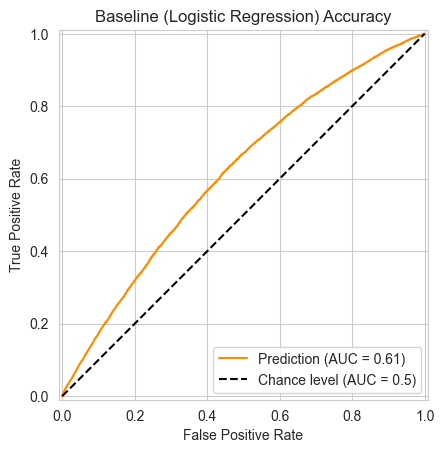

In [218]:
%%time

display = RocCurveDisplay.from_predictions( 
    y_val, 
    predict(model, vectorizer, df_val),
    name=f"Prediction",
    color="darkorange",
    plot_chance_level=True,
    # despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Baseline (Logistic Regression) Accuracy",
)

In [219]:
categorical_features(dfLoans_processed)


[
    'branch_id',
    'supplier_id',
    'manufacturer_id',
    'current_pincode_id',
    'state_id',
    'employee_code_id',
    'perform_cns_score_description'
]

In [220]:
print(sorted(vectorizer.feature_names_))

[
    'aadhar_flag',
    'asset_cost_scaled',
    'average_acct_age',
    'branch_id',
    'credit_history_length',
    'current_pincode_id',
    'date_of_birth_dow',
    'date_of_birth_is_weekend',
    'date_of_birth_month',
    'date_of_birth_quarter',
    'date_of_birth_year',
    'delinquent_accts_in_last_six_months',
    'disbursal_date_dow',
    'disbursal_date_is_weekend',
    'disbursal_date_month',
    'disbursal_date_quarter',
    'disbursal_date_year',
    'disbursed_amount_scaled',
    'driving_flag',
    'employee_code_id',
    'ltv',
    'manufacturer_id',
    'mobileno_avl_flag',
    'new_accts_in_last_six_months',
    'no_of_inquiries',
    'pan_flag',
    'passport_flag',
    'perform_cns_score',
    'perform_cns_score_description=high',
    'perform_cns_score_description=low',
    'perform_cns_score_description=medium',
    'perform_cns_score_description=no history',
    'perform_cns_score_description=not scored',
    'perform_cns_score_description=very high',
    'perform_cns_score_description=very low',
    'pri_active_accts',
    'pri_current_balance_scaled',
    'pri_disbursed_amount_scaled',
    'pri_no_of_accts',
    'pri_overdue_accts',
    'pri_sanctioned_amount_scaled',
    'primary_instal_amt',
    'sec_active_accts',
    'sec_current_balance_scaled',
    'sec_disbursed_amount_scaled',
    'sec_instal_amt',
    'sec_no_of_accts',
    'sec_overdue_accts',
    'sec_sanctioned_amount_scaled',
    'state_id',
    'supplier_id',
    'voterid_flag'
]

In [221]:
X, _ = one_hot_encode(df_val, vectorizer, fit=False)

(
    pd.DataFrame(X, columns=vectorizer.feature_names_)
    [['perform_cns_score_description=not scored']]
    # .info()
    .head(20)
)

,perform_cns_score_description=not scored
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


Observation:

- 77% ROC AUC is quite welcomed; sets a baseline for tuning (higher is better)

#### Linear regression model tuning

In [ ]:
scores = []

for C in C_range:
    kfold = KFold(n_splits=folds, shuffle=True, random_state=seed)
    fold = 1
    
    for training_indices, validation_indices in tqdm(kfold.split(df_full), desc=f'{C = :>6}'):
        df_training   = df_full.iloc[training_indices]
        y_training    = y_full .iloc[training_indices]
        df_validation = df_full.iloc[validation_indices]
        y_validation  = y_full . iloc[validation_indices]
        
        model, vectorizer = fit(
            model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=C),
            dataframe=df_training,
            y=y_training
        )        
        y_pred = predict(model, vectorizer, df_validation)
        
        scores.append((C, fold, roc_auc_score(y_validation, y_pred)))
        fold += 1
        
_ = pd.DataFrame(scores, columns=['C', 'fold', 'auc'])
display(_.groupby(by='C').max())


best_C = _.groupby(by='C').max().sort_values(by='auc', ascending=False).index[0]
best_C

In [ ]:
model, vectorizer = fit(
    model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=best_C),
    dataframe=df_training,
    y=y_training
)

pd.DataFrame(zip(vectorizer.feature_names_, abs(model.coef_[0])), columns=['feature', 'importance']) \
    .sort_values(by='importance', ascending=False) \
        .tail(20)

Observation:

- `salary`, `ethnicity`, and `job_role` least significant features 

In [ ]:
scores = []
dropped_features = ['salary', 'gender', 'ethnicity', 'job_role']

# for dropped_feature_combo in [list(combo) for combo in [[], *combinations(dropped_features, 1), *combinations(dropped_features, 2), *combinations(dropped_features, 3), dropped_features]]:
for dropped_feature_combo in all_combinations_of(dropped_features):
    # display(dropped_feature_combo)
    for C in C_range:
        kfold = KFold(n_splits=folds, shuffle=True, random_state=seed)
        fold = 1
        
        for training_indices, validation_indices in tqdm(kfold.split(df_full), desc=f'{C = :>6}, {dropped_feature_combo = }'):
            df_training   = df_full.iloc[training_indices]
            y_training    = y_full .iloc[training_indices]
            df_validation = df_full.iloc[validation_indices]
            y_validation  = y_full . iloc[validation_indices]
            
            model, vectorizer = fit(
                model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=C),
                dataframe=df_training,
                y=y_training,
                drop=dropped_feature_combo
            )        
            y_pred = predict(model, vectorizer, df_validation, drop=dropped_feature_combo)
            
            scores.append((dropped_feature_combo, C, fold, roc_auc_score(y_validation, y_pred)))
            fold += 1
        
_ = pd.DataFrame(scores, columns=['dropped_features', 'C', 'fold', 'auc']) \
    .groupby(by='C').max().sort_values(by='auc', ascending=False)
display(_)

best_C = _.index[0]
dropped_features = _.iloc[0]['dropped_features']

best_tuning = {
    'logistic': {
        'seed': seed,
        'dropped_features': dropped_features,
        'C': best_C,
        }
    }
dropped_features, best_C

In [ ]:
model, vectorizer = fit(
    model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=best_C),
    dataframe=df_train,
    y=y_train,
    drop=dropped_features
)

y_val_pred = predict(model, vectorizer, df_val, drop=dropped_features)
fpr, tpr, _ = roc_curve(y_val, y_val_pred)
roc_auc_score(y_val, y_val_pred).round(3)

Observation:

- 97% ROC AUC is very good (perhaps too good?), achieved by dropping `dropped_features` and setting C=`best_C`

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='random', linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

### Random Forest Evaluation Model

In [ ]:
model, vectorizer = fit(
    model=RandomForestRegressor(n_estimators=10, random_state=seed, n_jobs=-1), 
    vectorizer=DictVectorizer(sparse=True),
    dataframe=df_train, 
    y=y_train,
)
y_val_pred = decide(model, vectorizer, df_val)
root_mean_squared_error(y_val, y_val_pred).round(3)

#### Random Forest model tuning

In [ ]:
pd.DataFrame(zip(vectorizer.feature_names_, model.feature_importances_), columns=['feature', 'importance']) \
    .sort_values(by='importance', ascending=False) \
        .tail(20)

In [ ]:
scores = []
dropped_features = ['salary', 'gender', 'ethnicity', 'job_role'] # for consistency with Logistic Regression

for dropped_feature_combo in all_combinations_of(dropped_features):
    # display(dropped_feature_combo)
    for estimators in estimators_range:
        for max_depth in tqdm(max_depth_range, f'{dropped_feature_combo = } {estimators= :>2}'):
            model, vectorizer = fit(
                model=RandomForestRegressor(max_depth=max_depth, n_estimators=estimators, random_state=seed, n_jobs=-1), 
                vectorizer=DictVectorizer(sparse=True),
                dataframe=df_train, 
                y=y_train,
                drop=dropped_feature_combo
            )
            
            y_val_pred = decide(model, vectorizer, df_val, drop=dropped_feature_combo)
            
            scores.append(('-'.join(dropped_feature_combo), max_depth, estimators, root_mean_squared_error(y_val, y_val_pred)))
        
_ = pd.DataFrame(scores, columns=['dropped_features', 'max_depth', 'estimators', 'rmse']) \
    .sort_values(by='rmse')
display(_.head(10))

dropped_features, best_depth, best_estimators = _.iloc[0, 0:3]  # First row, first 3 columns
dropped_features = dropped_features.split('-')
best_tuning['random_forest'] = {
    'seed': seed,
    'dropped_features': dropped_features,
    'depth': best_depth,
    'estimators': best_estimators,
    }
dropped_features, best_depth, best_estimators

In [ ]:
model, vectorizer = fit(
    model=RandomForestRegressor(max_depth=best_depth, n_estimators=best_estimators, random_state=seed, n_jobs=-1), 
    vectorizer=DictVectorizer(sparse=True),
    dataframe=df_train, 
    y=y_train,
    drop=dropped_features
)
            
y_val_pred = decide(model, vectorizer, df_val, drop=dropped_features)
fpr, tpr, _ = roc_curve(y_val, y_val_pred)
roc_auc_score(y_val, y_val_pred).round(3)

Observation:

- 96% ROC AUC is very good (and consistent with the tuned Logistic Regression model), achieved by dropping dropped_features=`dropped_features` and setting max_depth=`best_depth` and n_estimators=`best_estimators`

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='random', linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

### Gradient Boosting model

In [ ]:
scores = []

for eta in boost_eta_range:
    for depth in tqdm(max_depth_range, desc=f'{eta = }'):
        xgb_params = {
            'eta': eta, 
            'max_depth': depth,
            'min_child_weight': 1,
            
            'objective': 'reg:squarederror',
            'nthread': 2,
            
            'seed': seed,
            'verbosity': 1,
        }
        
        X_train, vectorizer = one_hot_encode(df_train, vectorizer=DictVectorizer(sparse=True), fit=True)
        X_val, _ = one_hot_encode(df_val, vectorizer=vectorizer)
        
        dX_train = xgb.DMatrix(X_train, label=y_train, feature_names=vectorizer.feature_names_)
        dX_val = xgb.DMatrix(X_val, label=y_val, feature_names=vectorizer.feature_names_)
        
        model = xgb.train(xgb_params, dX_train, num_boost_round=100)
        y_val_pred = model.predict(dX_val)
        
        scores.append((eta, depth, xgb_params, root_mean_squared_error(y_val, y_val_pred)))
        
_ = pd.DataFrame(scores, columns=['eta', 'max_depth', 'xgb_params', 'rmse']) \
    .sort_values(by='rmse')
display(_.head(10))

best_xgb_params = _.iloc[0]['xgb_params']
best_tuning['boost'] = best_xgb_params
best_xgb_params

In [ ]:
X_train, vectorizer = one_hot_encode(df_train, vectorizer=DictVectorizer(sparse=True), fit=True)
X_val, _ = one_hot_encode(df_val, vectorizer=vectorizer)

dX_train = xgb.DMatrix(X_train, label=y_train, feature_names=vectorizer.feature_names_)
dX_val = xgb.DMatrix(X_val, label=y_val, feature_names=vectorizer.feature_names_)

model = xgb.train(best_xgb_params, dX_train, num_boost_round=100)
y_val_pred = model.predict(dX_val)

fpr, tpr, _ = roc_curve(y_val, y_val_pred)
roc_auc_score(y_val, y_val_pred).round(3)

Observation:

- 97% ROC AUC is very good (and consistent with the tuned Logistic Regression and Decision Tree models), achieved by setting xgb_params=`best_xgb_params`

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='random', linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

### Model Selection

When comparing the plotted False Positive vs False Negative rates, the **Logistic Regression** model is optimal despite it's ROC AUC score being the lowest of an exceptionally good bunch.

In [ ]:
display(best_tuning)

dropped_features = best_tuning['logistic']['dropped_features']
best_C = best_tuning['logistic']['C']
seed = best_tuning['logistic']['seed']

dropped_features, best_C, seed

In [ ]:
model, vectorizer = fit(
    model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=seed, C=best_C),
    dataframe=df_full,
    y=y_full,
    drop=dropped_features
)

model, vectorizer

**NOTE**:  Please refer to `./train_and_persist.py` for continued model persistence into `./models/` 